## The boxes information folder organization

In [14]:
|-- ./box_info 
  |-- cloud
    |-- 1637596878814245.npy
    |-- 1637596884914336.npy
    |-- ...
  |-- night
    |-- 1638481138115285.npy
    |-- 1638481146315409.npy
    |-- ...
  |-- rain
  |-- snow
  |-- sunny

SyntaxError: invalid syntax (353363549.py, line 1)

In [15]:
import json

# 1. 检查 weather.json 是否能正常读取
weather_path = "D:/Reproduce/DriveFit/DriveDiTFit/datasets/Ithaca365/v2.2/weather.json"

try:
    with open(weather_path, 'r', encoding='utf-8') as f:
        content = f.read()
        print(f"文件前100字符: {repr(content[:100])}")  # 检查是否有隐藏字符
        data = json.loads(content)
        print(f"✅ JSON 有效! 共 {len(data)} 条天气记录")
        for item in data:
            print(f"  - {item['description']}: {len(item['scenes'])} scenes")
except Exception as e:
    print(f"❌ 错误: {e}")

# 2. 重新写入文件（去除可能的隐藏字符）
try:
    with open(weather_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    with open(weather_path, 'w', encoding='utf-8', newline='\n') as f:
        json.dump(data, f, indent=4, ensure_ascii=False)
    print("✅ 文件已重新保存")
except Exception as e:
    print(f"❌ 保存失败: {e}")

文件前100字符: '[\n    {\n        "token": "f171a8c5d0a51f2f291072fa7e0913b4",\n        "description": "night",\n       '
✅ JSON 有效! 共 5 条天气记录
  - night: 9 scenes
  - sunny: 9 scenes
  - rain: 7 scenes
  - cloud: 9 scenes
  - snow: 6 scenes
✅ 文件已重新保存


In [10]:
import json
import os

v2_path = "D:/Reproduce/DriveFit/DriveDiTFit/datasets/Ithaca365/v2.2"

for filename in os.listdir(v2_path):
    if filename.endswith('.json'):
        filepath = os.path.join(v2_path, filename)
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
            with open(filepath, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=4)
            print(f"✅ Formatted: {filename}")
        except Exception as e:
            print(f"❌ Error in {filename}: {e}")

✅ Formatted: attribute.json
✅ Formatted: calibrated_sensor.json
✅ Formatted: category.json
✅ Formatted: ego_pose.json
✅ Formatted: instance.json
✅ Formatted: locations.json
✅ Formatted: log.json
✅ Formatted: map.json
✅ Formatted: object_ann.json
✅ Formatted: sample.json
✅ Formatted: sample_annotation.json
✅ Formatted: sample_data.json
✅ Formatted: scene.json
✅ Formatted: sensor.json
✅ Formatted: surface_ann.json
✅ Formatted: visibility.json
✅ Formatted: weather.json


In [16]:
from ithaca365.ithaca365 import Ithaca365
dataset = Ithaca365(version="v2.2", dataroot="D:/Reproduce/DriveFit/DriveDiTFit/datasets/Ithaca365", verbose=True)

Loading Ithaca365 tables for version v2.2...
7 category,
1 attribute,
4 visibility,
25839 instance,
5 sensor,
5 calibrated_sensor,
760811 ego_pose,
40 log,
40 scene,
6576 sample,
2282433 sample_data,
25839 sample_annotation,
1 map,
2579 location,


AttributeError: 'Ithaca365' object has no attribute 'weather'

In [22]:
import numpy as np 
sample=dataset.sample 

cam_token2time={}
for index in np.arange(len(sample)):
    cam_token2time[sample[index]['key_camera_token']]=sample[index]['timestamp']

object_ann=dataset.object_ann
object_dict={}
label=['bus','car','truck']
for index in np.arange(len(object_ann)):
    if object_ann[index]['class'] not in label:
        continue
    frame_token=object_ann[index]['sample_data_token']
    timestamp=cam_token2time[frame_token]
    if str(timestamp) not in object_dict:
        object_dict[str(timestamp)]=[object_ann[index]['bbox']]
    else: 
        object_dict[str(timestamp)].append(object_ann[index]['bbox'])

In [23]:
#origin size: 1920*1208
#resize : 256*256 
#scale factor: 7.5, 4.71875ooo
for timestamp,boxes in object_dict.items():
    for index in np.arange(len(boxes)):
        boxes[index]=[boxes[index][0]/7.5,boxes[index][1]/4.71875,boxes[index][2]/7.5,boxes[index][3]/4.71875]

In [24]:
import os 

#from pixel to latent
for timestamp,boxes in object_dict.items():
    for index in np.arange(len(boxes)):
        boxes[index]=[boxes[index][0]/8,boxes[index][1]/8,boxes[index][2]/8,boxes[index][3]/8]

# constant with scenario label in the ithaca365 dataset
label=['snow','rain','night','sunny','cloud']
for i in np.arange(5):
    cond=label[i]
    save_dir=f'./datasets/box_info/{cond}'
    os.makedirs(save_dir,exist_ok=True)
    for root,dir,files in os.walk(f'./datasets/Ithaca365/Ithaca365-scenario/{cond}',topdown =False):
        files=sorted(files)

        if not files:
            continue
        for index in np.arange(len(files)):
            mask = np.zeros((32,32))
            name = files[index].split('.')[0]
            
            if name in object_dict:
                for box in object_dict[name]:
                    if int(box[0])+1>=int(box[2]) or int(box[1])+1>=int(box[3]):
                        continue
                    mask[int(box[1]):int(box[3])+1,int(box[0]):int(box[2])+1]=1
            np.save(f"{save_dir}/{name}.npy",mask)

### Visualization

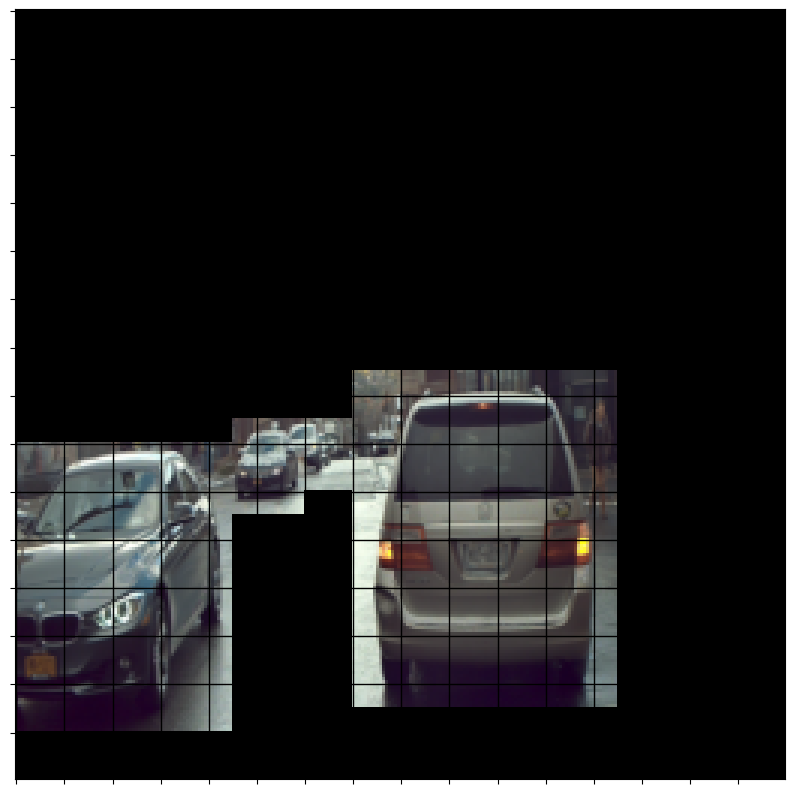

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
from PIL import Image

timestamp=1637679818611047
img=Image.open(f'./datasets/Ithaca365/Ithaca365-scenario/cloud/{timestamp}.png')
mask=np.load(f'./datasets/box_info/cloud/{timestamp}.npy')

mask_in = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(10, 10)) 
plt.imshow(np.array(np.array(img)*mask_in[:,:,None],dtype=np.uint8))
plt.xticks(np.arange(0, 256, 16),[])
plt.yticks(np.arange(0, 256, 16),[])
plt.grid(True, which='both', linestyle='-', linewidth=1, color='k')